# EXPT NO: 1 — Building and Training a Simple Artificial Neural Network (ANN) for Regression and Classification

# **TASK A**

24BAD049 - JESSICA SAM B
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Target  
0    -122.23   4.526  
1    -122.22   3.585  
2    -122.24   3.521  
3    -122.25   3.413  
4    -122.25   3.422  


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.8296 - mae: 0.6228 - val_loss: 0.4227 - val_mae: 0.4637
Epoch 2/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3824 - mae: 0.4413 - val_loss: 0.3994 - val_mae: 0.4381
Epoch 3/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3571 - mae: 0.4244 - val_loss: 0.3851 - val_mae: 0.4351
Epoch 4/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3434 - mae: 0.4138 - val_loss: 0.3776 - val_mae: 0.4285
Epoch 5/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3279 - mae: 0.4047 - val_loss: 0.3513 - val_mae: 0.4140
Epoch 6/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3243 - mae: 0.3982 - val_loss: 0.3635 - val_mae: 0.4088
Epoch 7/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3125 - mae: 0.3908 - val_loss: 0.3402 - val_mae: 0.4151
Epoch 8/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3103 - mae: 0.3879 - val_loss: 0.3493 - val_mae: 0.4081
Epoch 9/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - lo

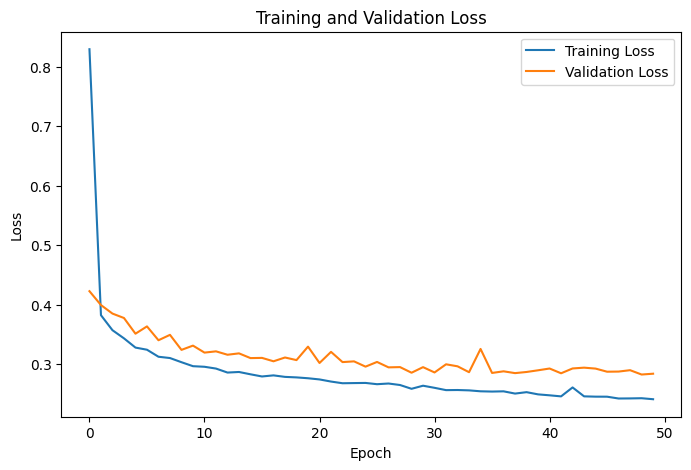

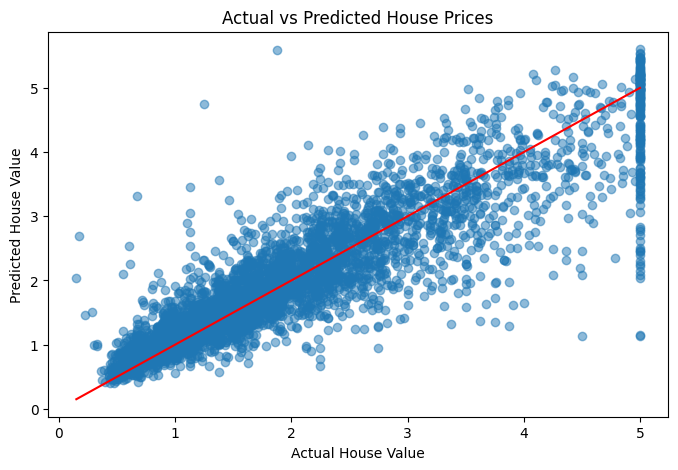


Sample Predictions
     Actual  Predicted
0   0.47700   0.403400
1   0.45800   0.850611
2   5.00001   5.302257
3   2.18600   2.409270
4   2.78000   2.933827
5   1.58700   1.716993
6   1.98200   2.435849
7   1.57500   1.602341
8   3.40000   2.459976
9   4.46600   4.939240
10  1.23200   1.162167
11  2.53900   1.869552
12  2.15100   1.443681
13  2.20500   1.850987
14  2.19800   2.545690
15  1.36200   1.597979
16  1.78400   2.032388
17  1.87500   1.803409
18  1.39800   1.561206
19  1.37500   1.104571


In [ ]:
print("24BAD049 - JESSICA SAM B")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
housing = fetch_california_housing()
X = housing.data
y = housing.target
feature_names = housing.feature_names
df = pd.DataFrame(X, columns=feature_names)
df["Target"] = y
print(df.head())
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1)
])
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("24BAD049 - JESSICA SAM B")
print("\nModel Evaluation")
print("Mean Squared Error (MSE):", mse)
print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted House Prices")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r')
plt.show()
results = pd.DataFrame({
    "Actual": y_test[:20],
    "Predicted": y_pred[:20].flatten()
})
print("\nSample Predictions")
print(results)

# **TASK** **B**

24BAD049-JESSICA SAM B
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.7995 - loss: 0.5071 - val_accuracy: 0.9341 - val_loss: 0.3737
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9313 - loss: 0.3159 - val_accuracy: 0.9560 - val_loss: 0.2319
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9423 - loss: 0.1987 - val_accuracy: 0.9560 - val_loss: 0.1640
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9615 - loss: 0.1369 - val_accuracy: 0.9670 - val_loss: 0.1322
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9725 - loss: 0.1028 - val_accuracy: 0.9670 - val_loss: 0.1160
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9780 - loss: 0.0842 - val_accuracy: 0.9670 - val_loss: 0.1057
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9780 - loss: 0.0713 - val_accuracy: 0.9670 - val_loss: 0.0981
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9863 - loss: 0.0626 - val_accuracy: 0.9670 - val_loss: 0.0932
Ep

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

Jessica sam - 24BAD049

Model Evaluation
Accuracy : 0.9736842105263158
Precision: 0.9594594594594594
Recall   : 1.0
F1-Score : 0.9793103448275862

Confusion Matrix
[[40  3]
 [ 0 71]]


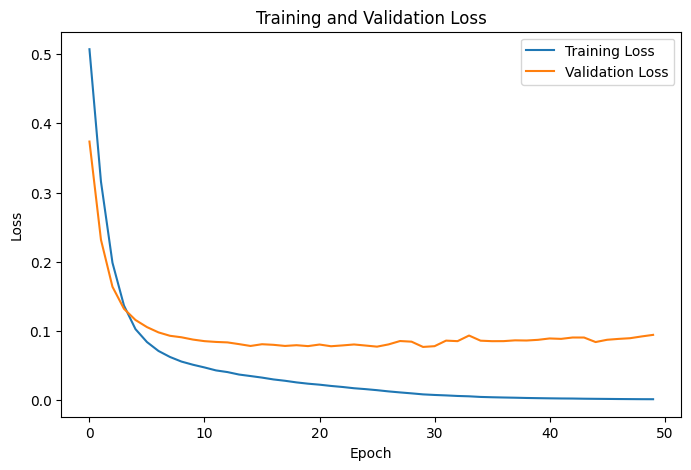

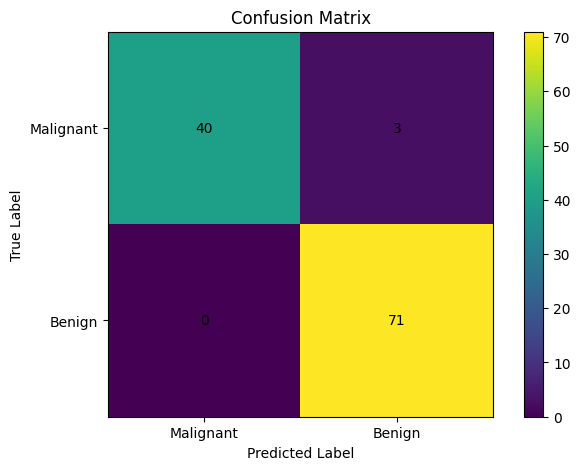


Sample Predictions
    Actual  Predicted
0        1          1
1        0          0
2        0          0
3        1          1
4        1          1
5        0          0
6        0          0
7        0          0
8        1          1
9        1          1
10       1          1
11       0          0
12       1          1
13       0          0
14       1          1
15       0          0
16       1          1
17       1          1
18       1          1
19       0          0


In [ ]:
print("24BAD049-JESSICA SAM B")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target
df = pd.DataFrame(X, columns=cancer.feature_names)
df["Target"] = y
print(df.head())
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)
y_prob = model.predict(X_test)
y_pred = (y_prob > 0.5).astype(int)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
print("\nJessica sam - 24BAD049")
print("\nModel Evaluation")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)
print("\nConfusion Matrix")
print(cm)
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()
plt.figure(figsize=(8,5))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1], ["Malignant", "Benign"])
plt.yticks([0, 1], ["Malignant", "Benign"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.show()
results = pd.DataFrame({
    "Actual": y_test[:20],
    "Predicted": y_pred[:20].flatten()
})
print("\nSample Predictions")
print(results)